download data: https://www.nyc.gov/site/tlc/about/about-tlc.page

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import pickle

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
import xgboost as xgb

from sklearn.metrics import root_mean_squared_error

import mlflow
from mlflow.tracking import MlflowClient

#### MLflow UI

MLflow provides a web-based User Interface (UI) to visualize and compare all your experiment runs. It makes it easier to analyze metrics, parameters, models, and artifacts in one place.

#### RUNNING MLflow UI LOCALLY

To launch the MLflow UI locally, run the following command:

> `mlflow server --backend-store-uri sqlite:///mlflow.db --host 127.0.0.1 --port 5000`

This command starts a local server and opens the MLflow dashboard at **`http://127.0.0.1:5000`**

---

In addition to the UI, an interface that is introduced in the course and used to automate processes is the Tracking API. Initialized through:

In [2]:
# MLFLOW_TRACKING_URI = "http://127.0.0.1:5000/"

# mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
# mlflow.set_experiment("nyc-new-brand-experiment_first")

# client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)

In [3]:
# ==============================================================================
# MLflow Configuration
# ==============================================================================
# MLflow is a tool that helps you track machine learning experiments.
# Think of it as a "lab notebook" that automatically records what you tried,
# what settings you used, and what results you got - so you can compare runs later.
# ==============================================================================


# ------------------------------------------------------------------------------
# Step 1: Choose where MLflow will store its data (the "Tracking URI")
# ------------------------------------------------------------------------------
# The Tracking URI tells MLflow where to save experiment records.
# There are two common options:

# OPTION A - MLflow Server (commented out here):
#   Starts a full web server in the background (run `mlflow server` in the terminal first).
#   Good for teams sharing results, but uses more RAM and requires the server to be running.
MLFLOW_TRACKING_URI = "http://127.0.0.1:5000/"

# OPTION B - SQLite local file (active option):
#   Saves everything directly into a local file called "mlflow.db".
#   No server needed. Lightweight and perfect for solo/local development.
#   MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"


# ------------------------------------------------------------------------------
# Step 2: Apply the Tracking URI to the MLflow session
# ------------------------------------------------------------------------------
# This line tells the MLflow library: "use THIS location to store and read data."
# It must be called before logging any runs or creating experiments.
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)


# ------------------------------------------------------------------------------
# Step 3: Name and activate the Experiment
# ------------------------------------------------------------------------------
# An "experiment" in MLflow is a named container that groups related runs together.
# For example, all the times you train a model on the NYC dataset go under one experiment.
# If this experiment name doesn't exist yet, MLflow creates it automatically.
mlflow.set_experiment("nyc-new-brand-experiment_first")


# ------------------------------------------------------------------------------
# Step 4: Create an MLflow Client
# ------------------------------------------------------------------------------
# The MlflowClient gives you programmatic (code-level) access to MLflow's data.
# While mlflow.set_experiment() is great for logging during training,
# the client lets you *query and manage* experiments, runs, and metrics after the fact.
# Example uses: listing all runs, comparing metrics, deleting old experiments.
client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)

2026/06/26 12:14:37 INFO mlflow.tracking.fluent: Experiment with name 'nyc-new-brand-experiment_first' does not exist. Creating a new experiment.


In [4]:
import pyarrow.parquet as pq

nrows = 10000 # ex: 10000 for testing, None for all rows
df = pq.read_table('data/yellow_tripdata_2023-01.parquet').slice(0, nrows).to_pandas()

df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

df = df[(df.duration >= 1) & (df.duration <= 60)]

categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

df[categorical] = df[categorical].astype(str)

In [5]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

5.546755376661107

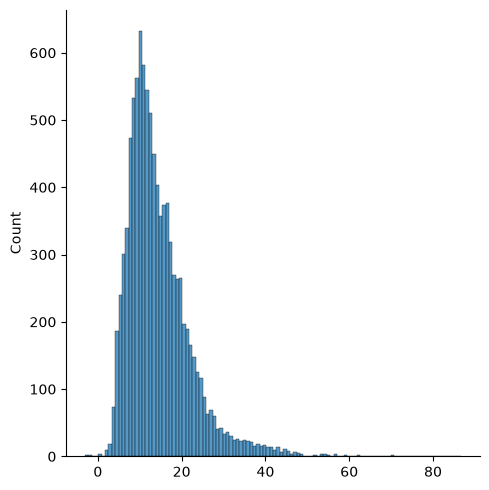

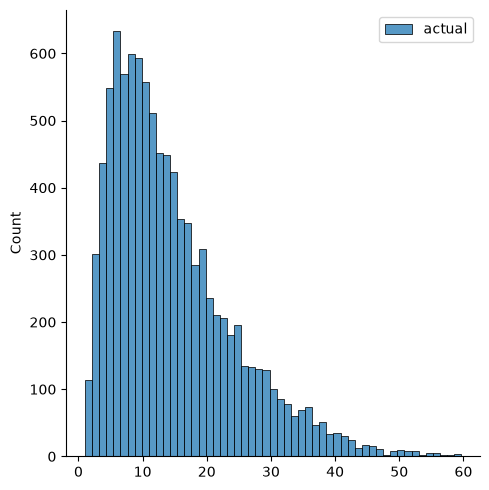

In [6]:
sns.displot(y_pred, label='prediction')
sns.displot(y_train, label='actual')

plt.legend()

In [7]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename, nrows=nrows)

        df.tpep_dropoff_datetime = pd.to_datetime(df.tpep_dropoff_datetime)
        df.tpep_pickup_datetime = pd.to_datetime(df.tpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pq.read_table(filename).slice(0, nrows).to_pandas()
        # df = pd.read_parquet(filename)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [8]:
df_train = read_dataframe('data/yellow_tripdata_2023-01.parquet')
df_val = read_dataframe('data/yellow_tripdata_2023-02.parquet')

In [9]:
len(df_train), len(df_val)

(9837, 9668)

In [10]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [11]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [12]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.360644844115528

In [14]:
with open('model/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

In [ ]:
with mlflow.start_run():
    
    mlflow.set_tag("developer", "niltonpegass")
    mlflow.log_param("train-data-path", "data/green_tripdata_2021-01.parquet")
    mlflow.log_param("valid-data-path", "data/green_tripdata_2021-02.parquet")
    
    alpha = 0.01
    mlflow.log_param("alpha", alpha)

    # ##
    X_train.indices = X_train.indices.astype('int32')
    X_train.indptr = X_train.indptr.astype('int32')

    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)

    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

    # ## the code below was added at the '2.4 MODEL MANAGEMENT' stage
    '''
    >> local_path is the path to the file you want to log, and artifact_path is the folder name in the MLflow UI where it will be stored.
    >> artifact_path is optional. If you don't specify it, the artifact will be stored in the root of the run's artifact directory.
       which is the location where mlflow will save your model artifacts. In this case, the model is saved in the 'models_pickle' folder in the MLflow UI.
    '''
    mlflow.log_artifact(local_path='model/lin_reg.bin', artifact_path='models_pickle/')

🏃 View run silent-skink-120 at: http://127.0.0.1:5000/#/experiments/1/runs/125fe32202d546e3ae0003c73d38204f
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


#### TRAINING XGBOOST

In [16]:
# -----------------------------------------------------------------------------
# SETUP NOTE (Python 3.14 + hyperopt 0.2.7 compatibility fix)
#
# hyperopt's atpe.py uses `pkg_resources`, which was dropped from setuptools>=81
# on Python 3.14. To reproduce this environment:
#
#   1. Ensure you are inside the pipenv virtualenv:
#        pipenv shell
#
#   2. Install a compatible setuptools version using the direct venv pip:
#        .local/share/virtualenvs/<your_venv_name>/bin/pip install "setuptools<81" --force-reinstall
#
#   3. Install hyperopt normally:
#        pipenv install hyperopt
#
#   The UserWarning about pkg_resources being deprecated is harmless for now.
#   Pin setuptools<81 until hyperopt releases a fix for this issue.
# -----------------------------------------------------------------------------

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [17]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [18]:
# IPython is used in Jupyter notebooks to control output display.
# clear_output() is a function that clears the current cell's output.
# In the context of hyperparameter optimization, it helps keep the notebook clean by removing intermediate logs after each trial.
# The `wait=True` argument tells it to wait until the next output is ready before clearing, which prevents flickering and ensures you see the latest results without clutter.
from IPython.display import clear_output

def objective(params):
    # Opens a new MLflow run to track this trial.
    # Everything logged inside this block is grouped under one run.
    with mlflow.start_run():

        # Tags this run with a label so you can filter by model type in the MLflow UI.
        # Logs all hyperparameters (e.g., learning_rate, max_depth) passed into this trial.
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)

        booster = xgb.train(
            params=params,                  # The hyperparameters being tested in this trial
            dtrain=train,                   # The training dataset (DMatrix format)
            num_boost_round=100,            # Maximum number of trees to build
            evals=[(valid, 'validation')],  # Monitors performance on the validation set
            early_stopping_rounds=50,       # Stops early if no improvement after 50 rounds
            verbose_eval=False              # Suppresses training output for cleaner logs (optional)
        )

        # Uses the trained model to generate predictions on the validation set.
        y_pred = booster.predict(valid)

        # Computes RMSE: measures the average prediction error.
        # Lower RMSE = better model performance.
        rmse = root_mean_squared_error(y_val, y_pred)

        # Logs the RMSE metric to MLflow so you can compare it across runs.
        mlflow.log_metric("rmse", rmse)

    clear_output(wait=True)                 # Clears the console output after each trial for cleaner logs (optional)

    # Returns the result to the optimizer.
    # 'loss' is what the optimizer tries to MINIMIZE (lower RMSE = better).
    # 'status' signals that this trial completed successfully.
    return {
        'loss': rmse,
        'status': STATUS_OK
    }

## `objective` Function

#### Overview

The `objective` function is the **core of the hyperparameter optimization loop**. It is designed to be called repeatedly by a hyperparameter search library (such as [Hyperopt](http://hyperopt.github.io/hyperopt/)) - each time with a different combination of model parameters. Its job is to:

1. Train an XGBoost model using the given parameters.
2. Evaluate how well the model performs (using RMSE).
3. Log everything to MLflow for experiment tracking.
4. Return the evaluation result so the optimizer knows whether this set of parameters was good or bad.

---

#### Parameter Breakdown

| Parameter / Variable | Type | Description |
|---|---|---|
| `params` | `dict` | A dictionary of XGBoost hyperparameters (e.g., `{"learning_rate": 0.1, "max_depth": 6}`). Passed in by the optimizer on each trial. |
| `train` | `xgb.DMatrix` | The training dataset, pre-converted to XGBoost's optimized matrix format. |
| `valid` | `xgb.DMatrix` | The validation dataset used to evaluate model quality during and after training. |
| `y_val` | `array-like` | The true target values for the validation set, used to compute RMSE. |
| `num_boost_round` | `int` | The maximum number of boosting iterations (trees) to train. |
| `early_stopping_rounds` | `int` | Training stops automatically if the validation score does not improve for this many consecutive rounds, preventing overfitting and saving time. |

---

#### What Is RMSE?

**Root Mean Squared Error (RMSE)** measures how far off your model's predictions are from the actual values, on average.

```
RMSE = sqrt( mean( (y_true - y_pred)² ) )
```

- A **lower RMSE** means the model's predictions are closer to the real values - which is what we want.
- It is used here as the **loss** (the value the optimizer tries to minimize).

---

#### Return Value

```python
{'loss': rmse, 'status': STATUS_OK}
```

| Key | Description |
|---|---|
| `loss` | The value the optimizer minimizes. Here it is the RMSE. |
| `status` | Signals to Hyperopt that the trial finished without errors (`STATUS_OK`). |

---

#### How This Fits Into the Bigger Picture

```
Hyperopt Optimizer
      │
      │  suggests a new set of params
      ▼
objective(params)
      │
      ├─ Trains XGBoost model
      ├─ Evaluates on validation set (RMSE)
      ├─ Logs everything to MLflow
      │
      └─ Returns {'loss': rmse, 'status': STATUS_OK}
             │
             ▼
      Optimizer learns from result
      and suggests better params next time
```

This loop runs for a fixed number of trials (set when you call `fmin()` or equivalent). At the end, the optimizer has explored many combinations of hyperparameters, and every trial is recorded in MLflow for comparison.

---

#### Tips and Common Gotchas

**`train` vs `valid` vs `y_val`:**
- `train` and `valid` are `xgb.DMatrix` objects (XGBoost's internal format, contains both features and labels).
- `y_val` is a plain NumPy array of the true labels for the validation set - needed separately to compute RMSE after prediction.

**`early_stopping_rounds=50`:**
- This is a safeguard against wasting compute. If the model stops improving on the validation set for 50 rounds in a row, training halts before reaching `num_boost_round=100`.

**Commented-out line:**
```python
# rmse = root_mean_squared_error(y_val, y_pred, squared=False)
```
Older versions of scikit-learn's `root_mean_squared_error` used a `squared=False` argument to return RMSE instead of MSE. Newer versions have a dedicated `root_mean_squared_error` function that does not need this argument. The active line uses the newer API.

**MLflow `with` block:**
- Using `with mlflow.start_run():` ensures the run is properly closed even if an error occurs during training - preventing orphaned/unfinished runs in your MLflow dashboard.

---

#### Prerequisites

The following must be defined before calling `objective`:

```python
import mlflow
import xgboost as xgb
from hyperopt import STATUS_OK
from sklearn.metrics import root_mean_squared_error

# These must exist in scope:
train   # xgb.DMatrix - training data
valid   # xgb.DMatrix - validation data
y_val   # array - true labels for validation set
```

In [19]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 50, 1)),
    'learning_rate': hp.loguniform('learning_rate', -2, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -2, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -4, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 2),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=Trials()
)

100%|██████████| 50/50 [02:01<00:00,  2.43s/trial, best loss: 5.471777721758267]


## Hyperparameter Search Space & Optimization

#### Overview

This cell does two things:

1. **Defines the search space** - the range of hyperparameter values that Hyperopt is allowed to explore.
2. **Runs the optimization** - repeatedly calls the `objective` function (up to 50 times), each time with a smarter guess at the best parameters, and records the best result found.

Think of it like a guided experiment: instead of manually trying hundreds of parameter combinations, you define the boundaries and let the optimizer intelligently search within them.

---

#### Part 1: The Search Space

```python
search_space = {
    'max_depth':        scope.int(hp.quniform('max_depth', 4, 50, 1)),
    'learning_rate':    hp.loguniform('learning_rate', -2, 0),
    'reg_alpha':        hp.loguniform('reg_alpha', -2, -1),
    'reg_lambda':       hp.loguniform('reg_lambda', -4, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 2),
    'objective':        'reg:linear',
    'seed':             42
}
```

Each key in this dictionary is an XGBoost hyperparameter. The value tells Hyperopt **how to sample** that parameter during each trial.

---

#### Hyperparameter Reference

#### `max_depth` - Tree Depth
```python
scope.int(hp.quniform('max_depth', 4, 50, 1))
```
- Controls how deep each decision tree can grow.
- **Range:** integers from `4` to `50`, stepping by `1`.
- **`hp.quniform(low, high, q)`** samples values uniformly across the range in steps of `q`.
- **`scope.int(...)`** converts the float output of `quniform` into a proper integer, which XGBoost requires.
- Deeper trees can model complex patterns but risk **overfitting**. Shallower trees are simpler and more generalizable.

---

#### `learning_rate` - Step Size per Boosting Round
```python
hp.loguniform('learning_rate', -2, 0)
```
- Controls how much each new tree corrects the errors of the previous ones.
- **Range:** `e⁻²` ≈ `0.135` to `e⁰` = `1.0`
- **`hp.loguniform(low, high)`** samples on a logarithmic scale - meaning small values (e.g. `0.01`) are explored just as thoroughly as large ones (e.g. `0.5`). This is appropriate because learning rate tends to matter more at smaller magnitudes.
- Lower values → more conservative learning → often better generalization, but requires more boosting rounds.

---

#### `reg_alpha` - L1 Regularization
```python
hp.loguniform('reg_alpha', -2, -1)
```
- Adds a penalty for the **absolute value** of leaf weights (L1 regularization).
- **Range:** `e⁻²` ≈ `0.135` to `e⁻¹` ≈ `0.368`
- Encourages the model to zero out less useful features (promotes sparsity).
- Higher values → stronger regularization → simpler model.

---

#### `reg_lambda` - L2 Regularization
```python
hp.loguniform('reg_lambda', -4, -1)
```
- Adds a penalty for the **squared value** of leaf weights (L2 regularization).
- **Range:** `e⁻⁴` ≈ `0.018` to `e⁻¹` ≈ `0.368`
- Discourages large weights, helping prevent overfitting without making features disappear entirely.
- XGBoost defaults `reg_lambda` to `1`; exploring smaller values here allows the model to be less constrained.

---

#### `min_child_weight` - Minimum Data in a Leaf
```python
hp.loguniform('min_child_weight', -1, 2)
```
- The minimum sum of instance weights (roughly: minimum number of samples) required to form a new leaf node.
- **Range:** `e⁻¹` ≈ `0.368` to `e²` ≈ `7.39`
- Higher values → the model requires more evidence before making a split → less overfitting.
- Lower values → the model can create splits from fewer data points → more complex trees.

---

#### `objective` - Loss Function
```python
'objective': 'reg:linear'
```
- Fixed value (not sampled). Tells XGBoost this is a **regression task** and to minimize a linear/squared loss.
- Note: `'reg:squarederror'` is the modern equivalent in newer XGBoost versions; `'reg:linear'` may produce a deprecation warning but still works.

---

#### `seed` - Random Seed
```python
'seed': 42
```
- Fixed value. Sets the random seed inside XGBoost for **reproducibility** - same data and params will always produce the same model.

---

#### Sampling Distribution Summary

| Parameter | Distribution | Approx. Range | Why This Distribution? |
|---|---|---|---|
| `max_depth` | Uniform (integer) | 4 – 50 | All tree depths equally plausible |
| `learning_rate` | Log-uniform | 0.135 – 1.0 | Small values matter as much as large |
| `reg_alpha` | Log-uniform | 0.135 – 0.368 | Regularization behaves multiplicatively |
| `reg_lambda` | Log-uniform | 0.018 – 0.368 | Same reasoning as reg_alpha |
| `min_child_weight` | Log-uniform | 0.37 – 7.39 | Wide range; log scale covers it evenly |

> **When to use `loguniform` vs `uniform`:**  
> Use `loguniform` when the parameter spans several orders of magnitude, or when a change from `0.001` to `0.01` is just as meaningful as a change from `0.1` to `1.0`. Use `uniform` when all values in the range are equally likely to be best.

---

#### Part 2: Running the Optimization

```python
best_result = fmin(
    fn=objective,       # The function to minimize
    space=search_space, # The parameter space to search within
    algo=tpe.suggest,   # The search algorithm (Tree-structured Parzen Estimator)
    max_evals=50,       # Number of trials to run
    trials=Trials()     # Object to store the history of all trials
)
```

#### Argument Breakdown

#### `fn=objective`
The function being optimized. Hyperopt will call `objective(params)` on every trial, where `params` is a new sample drawn from `search_space`. Hyperopt's goal is to find the `params` that make `objective` return the lowest `loss`.

---

#### `space=search_space`
The dictionary defined above. Hyperopt samples from it to generate `params` for each trial.

---

#### `algo=tpe.suggest`
The search strategy. **TPE (Tree-structured Parzen Estimator)** is a Bayesian optimization algorithm that learns from previous trials:

```
Trial 1:  random guess           → RMSE = 0.85
Trial 2:  informed guess         → RMSE = 0.72
Trial 3:  better-informed guess  → RMSE = 0.68
...
```

Unlike a random or grid search, TPE builds a probabilistic model of which parameter regions tend to produce low loss, and samples more frequently from those regions. It gets smarter with every trial.

---

#### `max_evals=50`
The total number of trials to run. Each trial = one full model training + evaluation. With 50 evals and XGBoost's early stopping, this is a reasonable balance between search thoroughness and compute time.

---

#### `trials=Trials()`
A Hyperopt object that records the full history of every trial: which parameters were used, what loss was returned, and how long it took. You can inspect it after the run:

```python
# See all trials as a list of dicts
trials.trials

# See all loss values
trials.losses()

# See the best result found
trials.best_trial
```

---

#### What Does `best_result` Contain?

`fmin` returns a plain dictionary with the **parameter values that achieved the lowest loss** across all 50 trials. Example:

```python
{
    'learning_rate': 0.213,
    'max_depth': 7,
    'min_child_weight': 1.45,
    'reg_alpha': 0.18,
    'reg_lambda': 0.09
}
```

> Note: `objective` and `seed` are not included because they were fixed values, not sampled parameters.

To use these parameters to retrain a final model:

```python
best_params = {**best_result, 'objective': 'reg:linear', 'seed': 42}
final_model = xgb.train(params=best_params, dtrain=train, num_boost_round=100)
```

---

#### End-to-End Flow

```
Define search_space
        │
        ▼
fmin() starts optimization loop (50 trials)
        │
        ├── Trial 1: sample params randomly → call objective(params) → get RMSE
        ├── Trial 2: TPE learns from Trial 1 → smarter sample → get RMSE
        ├── Trial 3: TPE learns from Trials 1–2 → smarter sample → get RMSE
        │   ...
        └── Trial 50: highly informed sample → get RMSE
        │
        ▼
best_result = params that produced the lowest RMSE across all 50 trials
All trials recorded in Trials() → visible in MLflow UI
```

---

#### Prerequisites

```python
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope
import xgboost as xgb
```

The `objective` function and the `train`, `valid`, `y_val` variables must also be defined before running this cell (see `objective` function documentation).

In [20]:
best_result

{'learning_rate': np.float64(0.13876907013950118),
 'max_depth': np.float64(4.0),
 'min_child_weight': np.float64(7.384827382923253),
 'reg_alpha': np.float64(0.28860874187692614),
 'reg_lambda': np.float64(0.3248923480933389)}

In [21]:
best_params = {
    'learning_rate': float(best_result['learning_rate']),
    'max_depth': int(best_result['max_depth']),
    'min_child_weight': int(best_result['min_child_weight']),
    'reg_alpha': float(best_result['reg_alpha']),
    'reg_lambda': float(best_result['reg_lambda']),
}

mlflow.xgboost.autolog()

booster = xgb.train(
            params=best_params,
            dtrain=train,
            num_boost_round=50,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )

2026/06/26 12:16:44 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'eab46753c47f4a02937629ec5d4c4652', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow


[0]	validation-rmse:9.09596
[1]	validation-rmse:8.33224
[2]	validation-rmse:7.71166
[3]	validation-rmse:7.21304
[4]	validation-rmse:6.82468
[5]	validation-rmse:6.51742
[6]	validation-rmse:6.26242
[7]	validation-rmse:6.07884
[8]	validation-rmse:5.92533
[9]	validation-rmse:5.81796
[10]	validation-rmse:5.72842
[11]	validation-rmse:5.65773
[12]	validation-rmse:5.61365
[13]	validation-rmse:5.58148
[14]	validation-rmse:5.55163
[15]	validation-rmse:5.52190
[16]	validation-rmse:5.50595
[17]	validation-rmse:5.49246
[18]	validation-rmse:5.48401
[19]	validation-rmse:5.47770
[20]	validation-rmse:5.47640
[21]	validation-rmse:5.46957
[22]	validation-rmse:5.46930
[23]	validation-rmse:5.46757
[24]	validation-rmse:5.46824
[25]	validation-rmse:5.46294
[26]	validation-rmse:5.46210
[27]	validation-rmse:5.46239
[28]	validation-rmse:5.46366
[29]	validation-rmse:5.46403
[30]	validation-rmse:5.46324
[31]	validation-rmse:5.46318
[32]	validation-rmse:5.46384
[33]	validation-rmse:5.46399
[34]	validation-rmse:5.4

2026/06/26 12:16:46 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2026/06/26 12:16:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run calm-auk-572 at: http://127.0.0.1:5000/#/experiments/1/runs/eab46753c47f4a02937629ec5d4c4652
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


### MODEL MANAGEMENT (SAVING AND LOADING MODELS WITH MLFLOW)

While the UI is fairly useful in selected a single model and also registering it. Often we will need to select models a little more "programatically". Additionally we will also need to tag which models we want to move to staging, then which ones to move to prod. This is one of the stages of model management.

### 2.4.1 Where does experiment tracking fit into model management and MLops?

Experiment tracking is usually the first stage of model management. However once we have our model this is only the first steps in it's lifecycle. The first version will usually get tested and then further changes/ammendments will need to be made to improve it. In some cases we may even need to revert back to previous forms of the model.

To determine whether or not models need changing, we need to monitor the performance of the models. If done purely manually this can quickly result in a disorganised mess that...
* Is error prone
* Doesn't have versioning
* Lacks model lineage

i.e. Don't use a whole load of folders. e.g. `final_final_model_v3.8`

So how can we save all these models automatically, with versioning, and keeping track of lineage?

### 2.4.2 MLflow log_artifact

>mlflow.log_artifact(local_path = "path/to/model.bin", artifact_path = "folder/for/models/)

When you go back to the MLflow UI and click on the run. in the artifacts section you should see a folder containing the model. You can then simply download the model and run it. NB with `auto_log()` the default path to artifacts is `./mlruns/<exp_num>/<run_id>/model/...`

But there is a faster way to save and load the model.

### 2.4.3 MLflow log_model()

For example

>mlflow.xgboost.log_model(booster, artifact_path=./path/to/artifact/)

NB I belive this is supported for a few libraries. e.g.

>mlflow.sklearn.log_model()

But if you want to custom models, or ones that are not supported by MLflow you can use

>mlflow.pyfunc.log_model()

This will make your model inherit the interface from the `PythonModel` class.

*NB log_model will run separately to the `auto_log` version. You need to disable auto_log with the line `mlflow.xgboost.auto_log(disable=True)`*

The interesting file output here is the `MLmodel` file which stores information on the
* `artifact_path`: Where the model is stored
* `flavors`: How you can run the model. e.g. a `python_function` or it's own library such as `xgboost`.

You are also able to log any pre-processing steps as an artifact

```python
## Skipping code already typed earlier
## Save the dictioinary vectoriser
with open("models/preprocessor.b", "wb") as f_out:
    pickle.dump(dv, f_out)
mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")

## Now log the model
mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")
```

This will store the model in the preprocessor folder.

### 2.4.4 Making predictions with the model.

Within the MLflw UI there are also step by step instructions for how to make predictions with each model.

MLflow uses the URI to find the model. There are some example codes to use this with Pyfunc, and/or spark.

You could also load it with the xgboost flavour provided you have the model URI

>xgb_model = mlflow.xgboost.load_model(model_URI)

From there you can make predictions using `.predict()` or whatever your model flavour prescribes.